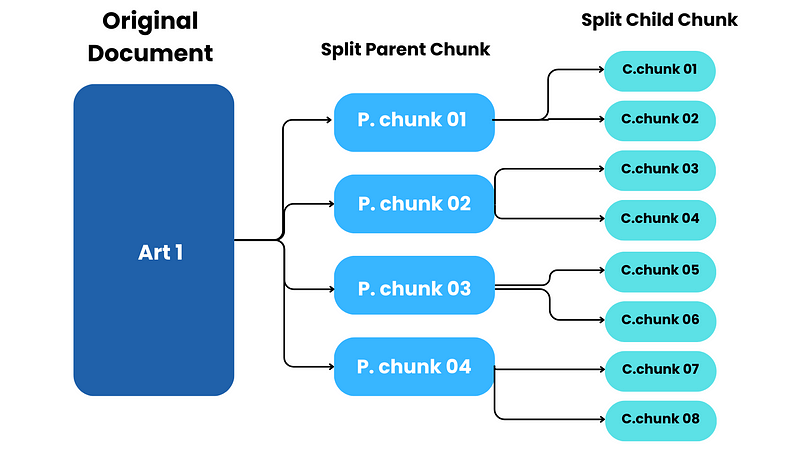

# Parent Document Retriever

which issue this parent-child retrieval will solve.

You may want to have small documents, so that their embeddings can most accurately reflect their meaning. If too long, then the embeddings can lose meaning.

You want to have long enough documents that the context of each chunk is retained.

The ParentDocumentRetriever strikes that balance by splitting and storing small chunks of data. During retrieval, it first fetches the small chunks but then looks up the parent ids for those chunks and returns those larger documents.

Note that "parent document" refers to the document that a small chunk originated from. This can either be the whole raw document OR a larger chunk.

In [ ]:
!pip install langchain

In [ ]:
!pip install -U langchain-community

In [ ]:
!pip install sentence-transformers

In [ ]:
!pip install langchain_chroma

In [ ]:
####if you want to use gemini feel free to use this code.

%pip install --upgrade --quiet  google-generativeai langchain-google-genai

# Data Ingestion

In [1]:
from langchain_community.document_loaders import TextLoader

In [2]:
loaders = [
    TextLoader(
        r"F:\Advance RAG\Data\paul_graham_essay.txt",
        encoding="utf-8"
    ),
    TextLoader(
        r"F:\Advance RAG\Data\state_of_the_union.txt",
        encoding="utf-8"
    ),
]

In [3]:
docs = []
for loader in loaders:
    docs.extend(loader.load())

In [100]:
len(docs)

2

In [5]:
# This text splitter is used to create the child documents
from langchain_text_splitters import RecursiveCharacterTextSplitter
child_splitter = RecursiveCharacterTextSplitter(chunk_size=400)

In [6]:
from langchain.storage import InMemoryStore
from langchain_chroma import Chroma

**Dataset size:**  Larger datasets generally benefit from more powerful models like MPNet.

**Computational resources:**  If you have limited resources, BGE Small En or MiniLM might be better options.

**Task complexity:**  For complex tasks like question answering or text summarization, MPNet is often preferred.

**Embedding dimensionality:**  Different models produce embeddings of varying dimensions.Choose based on downstream task requirements.

**Performance vs. efficiency trade-off:** Decide if you prioritize high accuracy or faster processing

#####Experimentation is key. Try different models and evaluate their performance on your specific task and dataset to find the best fit.

MTEB: Massive Text Embedding Benchmark

MPNET: Masked and Permuted Pre-training for Language Understanding.

BGE(BAAI general embedding)
BAAI: https://huggingface.co/BAAI

https://huggingface.co/sentence-transformers

https://huggingface.co/spaces/mteb/leaderboard

https://huggingface.co/blog/mteb

#### The all-mpnet-base-v2 model provides the best quality, while all-MiniLM-L6-v2 is 5 times faster and still offers good quality.

In [ ]:
'''# specify embedding model (using huggingface sentence transformer)
from langchain.embeddings import HuggingFaceEmbeddings
embedding_model_name = "sentence-transformers/all-mpnet-base-v2"
model_kwargs = {"device": "cuda"}
embeddings = HuggingFaceEmbeddings(
  model_name=embedding_model_name,
  model_kwargs=model_kwargs
)'''

In [17]:
from langchain_huggingface import HuggingFaceEmbeddings

In [18]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

In [20]:
vectorstore = Chroma(
    collection_name="full_documents", embedding_function=embeddings
)

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [21]:
store = InMemoryStore()

In [22]:
from langchain.retrievers import ParentDocumentRetriever
retriever = ParentDocumentRetriever(
    vectorstore=vectorstore,
    docstore=store,
    child_splitter=child_splitter,
)

In [23]:
retriever.add_documents(docs, ids=None)

In [24]:
list(store.yield_keys())

['57202db9-98fa-4c78-978d-2b14b32f95b1',
 '3525b462-d3b6-456b-9ec0-81d568115853']

In [25]:
retrieved_docs= retriever.invoke("What did the president say about Ketanji Brown Jackson")

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


In [101]:
len(retrieved_docs)

2

In [102]:
print(len(retrieved_docs[0].page_content))

38539


# Now using Parent Splitter

In [69]:
# It should create documents smaller than the parent
child_splitter = RecursiveCharacterTextSplitter(chunk_size=500)

In [70]:
# This text splitter is used to create the parent documents
parent_splitter = RecursiveCharacterTextSplitter(chunk_size=2000)

In [72]:
vectorstore1.delete_collection()

In [73]:
vectorstore1 = Chroma(
    collection_name="full_documents",
    embedding_function=embeddings
)

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [74]:
# The storage layer for the parent documents
store1 = InMemoryStore()

In [75]:
retriever2 = ParentDocumentRetriever(
    vectorstore=vectorstore1,
    docstore=store1,
    child_splitter=child_splitter,
    parent_splitter=parent_splitter,
)

In [76]:
retriever2.add_documents(docs)

In [77]:
len(list(store1.yield_keys()))

66

In [78]:
len(list(store.yield_keys()))

2

## View all child documents

In [80]:
# Get all child documents stored in the vector store
children = vectorstore1.get()

# Total number of child documents
print("Total Child Documents:", len(children["documents"]))

Total Child Documents: 358


In [81]:
# Display the first child document (small chunk)
print(children["documents"][0])

What I Worked On

February 2021

Before college the two main things I worked on, outside of school, were writing and programming. I didn't write essays. I wrote what beginning writers were supposed to write then, and probably still are: short stories. My stories were awful. They had hardly any plot, just characters with strong feelings, which I imagined made them deep.


In [82]:
# Display metadata of the first child document
# Metadata contains the parent document ID (doc_id)
print(children["metadatas"][0])

{'doc_id': '332c5f60-f561-4dad-b79f-c6814d7dd41c', 'source': 'F:\\Advance RAG\\Data\\paul_graham_essay.txt'}


## View all parent document 

In [83]:
# Get all parent document IDs stored in the docstore
parent_ids = list(store1.yield_keys())

print("Total Parent Documents:", len(parent_ids))
print(parent_ids[:5])   # Show first 5 IDs

Total Parent Documents: 66
['332c5f60-f561-4dad-b79f-c6814d7dd41c', 'd608c58f-5d2a-4649-b015-235153e1db47', '26593c4a-0792-4223-bd98-a7e90e400d24', 'ce43c19f-4a58-465c-92de-daac0ea2571c', 'ca3022c8-7114-4450-8942-09eed83dee67']


In [85]:
# Extract the parent ID from the child metadata
parent_id = children["metadatas"][0]["doc_id"]

# Retrieve the corresponding parent document
parent_doc = store1.mget([parent_id])[0]

print(parent_doc.page_content)

What I Worked On

February 2021

Before college the two main things I worked on, outside of school, were writing and programming. I didn't write essays. I wrote what beginning writers were supposed to write then, and probably still are: short stories. My stories were awful. They had hardly any plot, just characters with strong feelings, which I imagined made them deep.

The first programs I tried writing were on the IBM 1401 that our school district used for what was then called "data processing." This was in 9th grade, so I was 13 or 14. The school district's 1401 happened to be in the basement of our junior high school, and my friend Rich Draves and I got permission to use it. It was like a mini Bond villain's lair down there, with all these alien-looking machines — CPU, disk drives, printer, card reader — sitting up on a raised floor under bright fluorescent lights.

The language we used was an early version of Fortran. You had to type programs on punch cards, then stack them in the

In [86]:
# Display the child document
print("========== CHILD DOCUMENT ==========\n")
print(children["documents"][0])

# Display the corresponding parent document
parent_id = children["metadatas"][0]["doc_id"]
parent_doc = store1.mget([parent_id])[0]

print("\n========== PARENT DOCUMENT ==========\n")
print(parent_doc.page_content)

========== CHILD DOCUMENT ==========

What I Worked On

February 2021

Before college the two main things I worked on, outside of school, were writing and programming. I didn't write essays. I wrote what beginning writers were supposed to write then, and probably still are: short stories. My stories were awful. They had hardly any plot, just characters with strong feelings, which I imagined made them deep.

========== PARENT DOCUMENT ==========

What I Worked On

February 2021

Before college the two main things I worked on, outside of school, were writing and programming. I didn't write essays. I wrote what beginning writers were supposed to write then, and probably still are: short stories. My stories were awful. They had hardly any plot, just characters with strong feelings, which I imagined made them deep.

The first programs I tried writing were on the IBM 1401 that our school district used for what was then called "data processing." This was in 9th grade, so I was 13 or 14. The s

In [87]:
# Display the first 5 child-parent pairs
for i in range(5):

    child = children["documents"][i]
    parent_id = children["metadatas"][i]["doc_id"]
    parent = store1.mget([parent_id])[0]

    print(f"\n========== Pair {i+1} ==========")
    print("\nChild:\n")
    print(child)

    print("\nParent:\n")
    print(parent.page_content[:500])  # Show first 500 characters


========== Pair 1 ==========

Child:

What I Worked On

February 2021

Before college the two main things I worked on, outside of school, were writing and programming. I didn't write essays. I wrote what beginning writers were supposed to write then, and probably still are: short stories. My stories were awful. They had hardly any plot, just characters with strong feelings, which I imagined made them deep.

Parent:

What I Worked On

February 2021

Before college the two main things I worked on, outside of school, were writing and programming. I didn't write essays. I wrote what beginning writers were supposed to write then, and probably still are: short stories. My stories were awful. They had hardly any plot, just characters with strong feelings, which I imagined made them deep.

The first programs I tried writing were on the IBM 1401 that our school district used for what was then called "data processing

========== Pair 2 ==========

Child:

The first programs I tried writing were

## ParentDocumentRetriever Relationship

```text
Original Document
        │
        ▼
Parent Splitter
        │
        ▼
Parent Documents (Stored in `store1`)
        │
        ▼
Child Splitter
        │
        ▼
Child Documents (Stored in `vectorstore1`)
        │
        ▼
Each child stores its parent ID (`doc_id`)
        │
        ▼
Similarity Search
        │
        ▼
Child Retrieved
        │
        ▼
Parent Document Returned to the LLM
```

# Now moving to Retriever part

In [88]:
retrieved_docs2= retriever2.invoke("What did the president say about Ketanji Brown Jackson")

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


In [89]:
retrieved_docs2

[Document(metadata={'source': 'F:\\Advance RAG\\Data\\state_of_the_union.txt'}, page_content='In state after state, new laws have been passed, not only to suppress the vote, but to subvert entire elections. \n\nWe cannot let this happen. \n\nTonight. I call on the Senate to: Pass the Freedom to Vote Act. Pass the John Lewis Voting Rights Act. And while you’re at it, pass the Disclose Act so Americans can know who is funding our elections. \n\nTonight, I’d like to honor someone who has dedicated his life to serve this country: Justice Stephen Breyer—an Army veteran, Constitutional scholar, and retiring Justice of the United States Supreme Court. Justice Breyer, thank you for your service. \n\nOne of the most serious constitutional responsibilities a President has is nominating someone to serve on the United States Supreme Court. \n\nAnd I did that 4 days ago, when I nominated Circuit Court of Appeals Judge Ketanji Brown Jackson. One of our nation’s top legal minds, who will continue Jus

In [91]:
len(retrieved_docs2[0].page_content)

1849

In [92]:
# Retrieve the child chunks from the vector store
child_docs = vectorstore1.similarity_search(
    "What did the president say about Ketanji Brown Jackson",
    k=4
)

# Display the retrieved child chunks
for i, doc in enumerate(child_docs, 1):
    print(f"\n========== Child Chunk {i} ==========\n")
    print(doc.page_content)
    print("\nMetadata:", doc.metadata)


========== Child Chunk 1 ==========

One of the most serious constitutional responsibilities a President has is nominating someone to serve on the United States Supreme Court. 

And I did that 4 days ago, when I nominated Circuit Court of Appeals Judge Ketanji Brown Jackson. One of our nation’s top legal minds, who will continue Justice Breyer’s legacy of excellence.

Metadata: {'doc_id': '91fe90b9-c34f-4855-960b-4dc86819bc66', 'source': 'F:\\Advance RAG\\Data\\state_of_the_union.txt'}

========== Child Chunk 2 ==========

When we asked Sam if he wanted to be president of YC, initially he said no. He wanted to start a startup to make nuclear reactors. But I kept at it, and in October 2013 he finally agreed. We decided he'd take over starting with the winter 2014 batch. For the rest of 2013 I left running YC more and more to Sam, partly so he could learn the job, and partly because I was focused on my mother, whose cancer had returned.

Metadata: {'doc_id': '5b334743-1a2c-4910-bc46-315

In [94]:
# Retrieve child chunks
child_docs = vectorstore1.similarity_search(
    "What did the president say about Ketanji Brown Jackson",
    k=3
)

# Retrieve parent documents
parent_docs = retriever2.invoke(
    "What did the president say about Ketanji Brown Jackson"
)

print("========== CHILD CHUNK ==========\n")
print(child_docs[0].page_content)

print("\n" + "=" * 80 + "\n")

print("========== PARENT DOCUMENT ==========\n")
print(parent_docs[0].page_content)

========== CHILD CHUNK ==========

One of the most serious constitutional responsibilities a President has is nominating someone to serve on the United States Supreme Court. 

And I did that 4 days ago, when I nominated Circuit Court of Appeals Judge Ketanji Brown Jackson. One of our nation’s top legal minds, who will continue Justice Breyer’s legacy of excellence.


========== PARENT DOCUMENT ==========

In state after state, new laws have been passed, not only to suppress the vote, but to subvert entire elections. 

We cannot let this happen. 

Tonight. I call on the Senate to: Pass the Freedom to Vote Act. Pass the John Lewis Voting Rights Act. And while you’re at it, pass the Disclose Act so Americans can know who is funding our elections. 

Tonight, I’d like to honor someone who has dedicated his life to serve this country: Justice Stephen Breyer—an Army veteran, Constitutional scholar, and retiring Justice of the United States Supreme Court. Justice Breyer, thank you for your ser

## ParentDocumentRetriever Retrieval Flow

```text
Query
   │
   ▼
Vector Store
   │
   ▼
Child Chunks Retrieved
   │
   ▼
ParentDocumentRetriever
   │
   ▼
Maps child `doc_id` → Parent Document
   │
   ▼
Returns Parent Documents to the LLM
```

### Retrieval Methods

- `vectorstore1.similarity_search(...)` → Returns **Child Chunks**
- `retriever2.invoke(...)` → Returns **Parent Documents**

# Data Generation

In [96]:
from dotenv import load_dotenv
import os

load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [97]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=GROQ_API_KEY,
    temperature=0,
)

result = llm.invoke("Write a ballad about LangChain")
print(result.content)

(Verse 1)
In realms of code, where minds entwine,
A chain of thought, did newly shine,
LangChain, a name, that echoes wide,
A framework born, to AI's inside.

(Chorus)
Oh LangChain, a wondrous might,
Weaving language, through day and night,
A tapestry rich, of thought and dream,
Where human touch, and AI's theme.

(Verse 2)
With LLMs, as its guiding light,
It navigates, the darkest night,
Through prompts and chains, it finds its way,
And generates, a new dawn's ray.

(Chorus)
Oh LangChain, a wondrous might,
Weaving language, through day and night,
A tapestry rich, of thought and dream,
Where human touch, and AI's theme.

(Verse 3)
From chatbots, to writers' aid,
It lends its hand, to those who've strayed,
In realms of text, it finds its voice,
And whispers secrets, of a digital choice.

(Chorus)
Oh LangChain, a wondrous might,
Weaving language, through day and night,
A tapestry rich, of thought and dream,
Where human touch, and AI's theme.

(Bridge)
As the chain grows, and the links un

In [98]:
from langchain.chains import RetrievalQA
from langchain.llms import OpenAI

qa = RetrievalQA.from_chain_type(llm=llm,
                                 chain_type="stuff",
                                 retriever=retriever2)

query = "What did the president say about Ketanji Brown Jackson"

In [99]:
qa.run(query)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11280\2828950282.py:1: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use invoke instead.
  qa.run(query)


'The President said that he nominated Circuit Court of Appeals Judge Ketanji Brown Jackson to serve on the United States Supreme Court, 4 days prior to the speech. He described her as "one of our nation\'s top legal minds" who will continue Justice Breyer\'s legacy of excellence. He also mentioned that she has a broad range of support, including from the Fraternal Order of Police and former judges appointed by both Democrats and Republicans. Additionally, he highlighted her background as a former top litigator in private practice, a former federal public defender, and from a family of public school educators and police officers, and described her as a "consensus builder".'

'The President said that he nominated Circuit Court of Appeals Judge Ketanji Brown Jackson to serve on the United States Supreme Court, 4 days prior to the speech. He described her as "one of our nation\'s top legal minds" who will continue Justice Breyer\'s legacy of excellence. He also mentioned that she has a broad range of support, including from the Fraternal Order of Police and former judges appointed by both Democrats and Republicans. Additionally, he highlighted her background as a former top litigator in private practice, a former federal public defender, and from a family of public school educators and police officers, and described her as a "consensus builder".'

## Conclusion

This notebook explored the parent document retrieval pattern as a practical answer to the tension between chunk size and preserved context in retrieval systems.

The first approach, built in Category 4, used only a child splitter and treated each entire original document as its own parent. This guaranteed that no context was ever lost, since the full document was always available, but it also meant that a single matched chunk could pull in an entire, potentially very long document as context for the language model.

The second approach, built in Category 5, introduced a parent splitter as well, so that each original document was first broken into medium sized parent chunks, and only those parent chunks were further broken into small child chunks for embedding. This produced parent documents that were meaningfully smaller and more focused than a whole file, while still being noticeably larger and more context rich than the small child chunks that similarity search actually matched against.

Exploring the vector store and the docstore directly in Category 6 made this relationship concrete, showing exactly how each small child chunk carries a `doc_id` in its metadata that maps back to a specific parent chunk, and Category 7 confirmed the practical effect by comparing raw child chunk retrieval against full parent document retrieval on the same question. Finally, Category 8 connected the parent document retriever to a Groq hosted language model through a `RetrievalQA` chain, producing a complete, accurately grounded answer about a real passage in the state of the union address.

The overall takeaway is that parent document retrieval lets a system search with the precision of small embeddings while still answering with the context of larger passages, and choosing whether the parent should be a whole document or a bounded parent chunk is itself a useful tuning decision depending on how long the source documents are and how much surrounding context a typical question actually needs.
